Load the dataset

In [ ]:
import pandas as pd

df = pd.read_csv("Tweets.csv") 
df.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


Clean the tweets

In [2]:
import re

def clean_tweet(tweet):
    tweet = re.sub(r'http\S+|www\S+|https\S+', '', tweet)  # Remove URLs
    tweet = re.sub(r'\@\w+|\#','', tweet)  # Remove mentions and hashtags
    tweet = re.sub(r'[^A-Za-z\s]', '', tweet)  # Remove numbers & special chars
    tweet = tweet.strip()
    return tweet

df['cleaned_text'] = df['text'].apply(clean_tweet)

In [3]:
df['cleaned_text']

0                                               What  said
1        plus youve added commercials to the experience...
2        I didnt today Must mean I need to take another...
3        its really aggressive to blast obnoxious enter...
4                  and its a really big bad thing about it
                               ...                        
14635    thank you we got on a different flight to Chicago
14636    leaving over  minutes Late Flight No warnings ...
14637         Please bring American Airlines to BlackBerry
14638    you have my money you change my flight and don...
14639    we have  ppl so we need  know how many seats a...
Name: cleaned_text, Length: 14640, dtype: object

Sentiment Analysis using VADER

In [5]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

def get_sentiment(tweet):
    score = analyzer.polarity_scores(tweet)['compound']
    if score >= 0.05:
        return 'positive'
    elif score <= -0.05:
        return 'negative'
    else:
        return 'neutral'

df['predicted_sentiment'] = df['cleaned_text'].apply(get_sentiment)
df['compound_score'] = df['cleaned_text'].apply(lambda x: analyzer.polarity_scores(x)['compound'])


Plot Sentiment Distribution

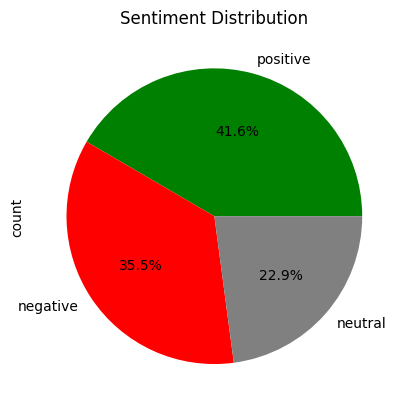

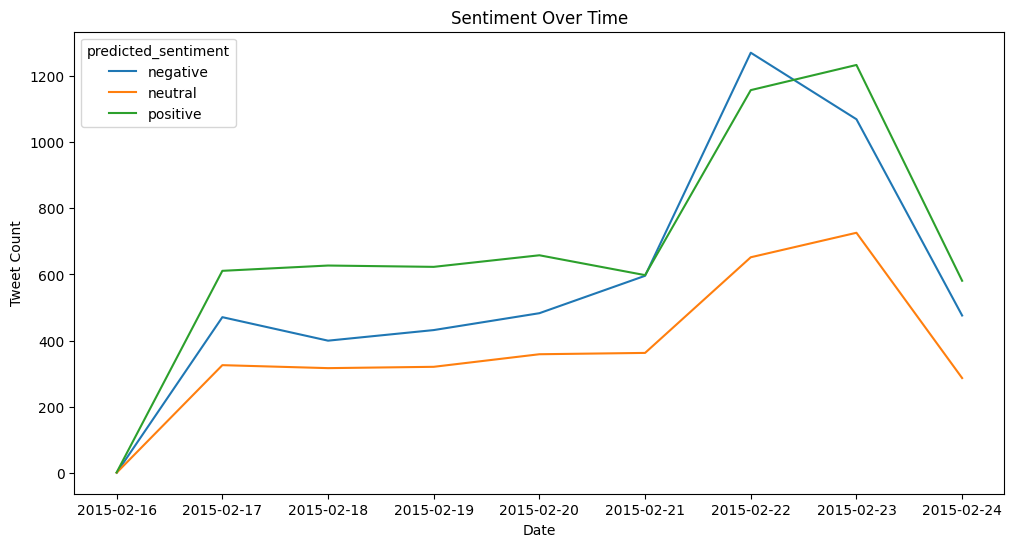

In [5]:
import matplotlib.pyplot as plt

# Pie chart
df['predicted_sentiment'].value_counts().plot.pie(autopct='%1.1f%%', colors=['green','red','grey'])
plt.title("Sentiment Distribution")
plt.show()

# Over time
df['tweet_created'] = pd.to_datetime(df['tweet_created'])
sentiment_over_time = df.groupby([df['tweet_created'].dt.date, 'predicted_sentiment']).size().unstack().fillna(0)
sentiment_over_time.plot(kind='line', figsize=(12,6))
plt.title("Sentiment Over Time")
plt.xlabel("Date")
plt.ylabel("Tweet Count")
plt.show()


Most positive & Negative Tweets

In [6]:
most_positive = df.loc[df['compound_score'].idxmax()]
most_negative = df.loc[df['compound_score'].idxmin()]

print("Most Positive Tweet:\n", most_positive['text'])
print("\nMost Negative Tweet:\n", most_negative['text'])


Most Positive Tweet:
 Thank U 😘 “@JetBlue: @ItsLaLoca But of course! Safety is always 1st!  We'll make sure to handle her with CARE and LOVE!  :)”

Most Negative Tweet:
 @united is the worst. Worst reservation policies. Worst costumer service. Worst worst worst. Congrats, @Delta you're not that bad!


Word clouds

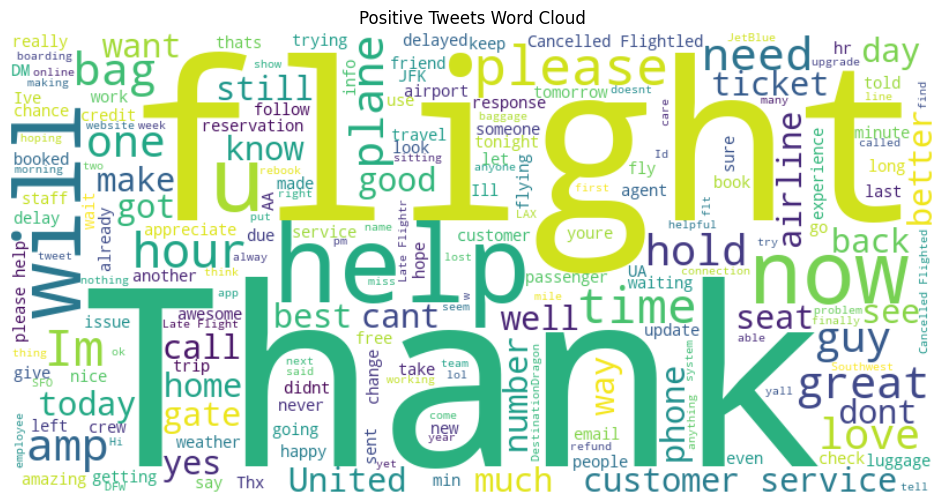

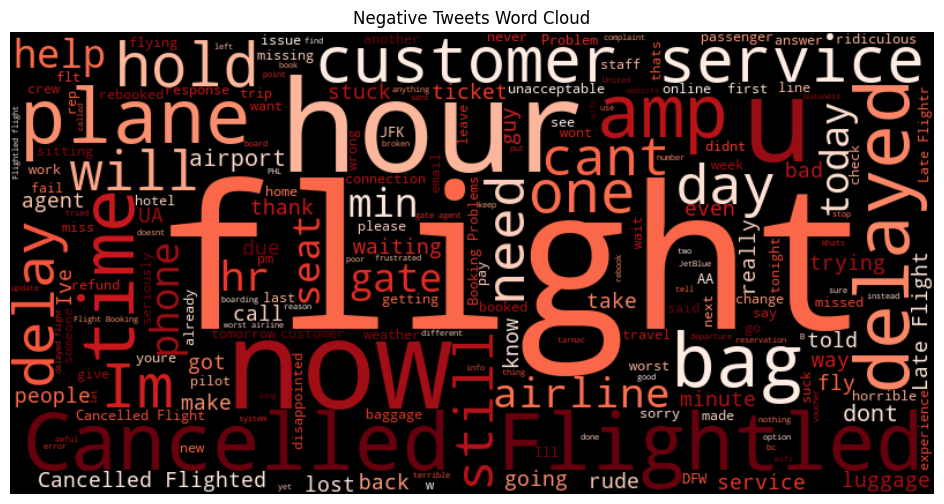

In [10]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Join all positive and negative tweets
positive_text = " ".join(df[df['predicted_sentiment']=='positive']['cleaned_text'])
negative_text = " ".join(df[df['predicted_sentiment']=='negative']['cleaned_text'])

# Positive Word Cloud
wordcloud_pos = WordCloud(width=800, height=400, background_color='white').generate(positive_text)
plt.figure(figsize=(12,6))
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.axis('off')
plt.title("Positive Tweets Word Cloud")
plt.show()

# Negative Word Cloud
wordcloud_neg = WordCloud(width=800, height=400, background_color='black', colormap='Reds').generate(negative_text)
plt.figure(figsize=(12,6))
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.axis('off')
plt.title("Negative Tweets Word Cloud")
plt.show()


Accuracy Check

In [11]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(df['airline_sentiment'], df['predicted_sentiment'])
print(f"Accuracy: {accuracy*100:.2f}%")
print(classification_report(df['airline_sentiment'], df['predicted_sentiment']))


Accuracy: 54.92%
              precision    recall  f1-score   support

    negative       0.90      0.51      0.65      9178
     neutral       0.39      0.42      0.40      3099
    positive       0.34      0.87      0.49      2363

    accuracy                           0.55     14640
   macro avg       0.54      0.60      0.51     14640
weighted avg       0.70      0.55      0.57     14640



Initial dataset shape: (14640, 15)
After keeping required columns: (14640, 2)
label
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64
                                                              tweet_text                                          cleaned_text
                                     @VirginAmerica What @dhepburn said.                                             what said
@VirginAmerica plus you've added commercials to the experience... tacky. plus you ve added commercials to the experience tacky
 @VirginAmerica I didn't today... Must mean I need to take another trip!  i didn t today must mean i need to take another trip
Train / Test sizes: 11712 2928
Fitting 5 folds for each of 4 candidates, totalling 20 fits


c:\Users\HP\Desktop\sem 3 college\class\lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


Best params: {'C': 1}
Cross-validated F1-macro on train: 0.7081922781071783 ± 0.005425075318348015

=== ML Model Test Performance ===
Accuracy: 0.7817622950819673
Macro F1: 0.7152406836492489

Classification Report:
               precision    recall  f1-score   support

    negative       0.84      0.89      0.86      1835
     neutral       0.62      0.56      0.59       620
    positive       0.73      0.66      0.69       473

    accuracy                           0.78      2928
   macro avg       0.73      0.70      0.72      2928
weighted avg       0.78      0.78      0.78      2928



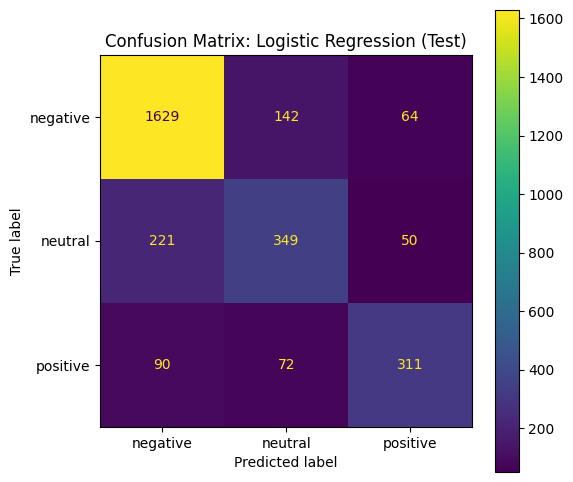


=== VADER Performance on SAME Test Set ===
Accuracy (VADER): 0.5437158469945356
Macro F1 (VADER): 0.5158235282840057

VADER Classification Report:
               precision    recall  f1-score   support

    negative       0.90      0.49      0.63      1835
     neutral       0.42      0.45      0.43       620
    positive       0.33      0.88      0.48       473

    accuracy                           0.54      2928
   macro avg       0.55      0.61      0.52      2928
weighted avg       0.70      0.54      0.57      2928



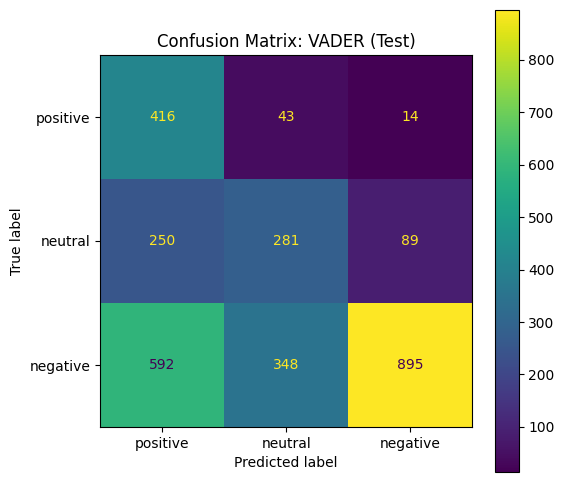

Saved model and vectorizer to disk.

Sample ML errors:
                                                                                                                       orig_text true_label  ml_pred vader_pred
                                                                   our fleet s on fleek really jetblue fleek hell no yall petty   negative  neutral   negative
  i just learned that although there is travel policy and they waive the change fee you will still be charged a reservation fee   negative  neutral   negative
i do to as i have an afternoon conference in las vegas and i would rather plan ahead than run thru the airport and then attempt   negative  neutral    neutral
                                       companion pass because everyone deserves redcarpet treatment and a even if it s your mom   positive  neutral    neutral
                                                               if you have well priced flights to oahu we could be best friends    neutral positive  

In [ ]:
# sentiment_ml_compare.py
# Requirements:
# pip install pandas scikit-learn matplotlib joblib vaderSentiment wordcloud


import pandas as pd
import re
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, precision_score, recall_score
)
import matplotlib.pyplot as plt
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import joblib

# ---------------------------
# 1. Load dataset
# ---------------------------
# Update the path to your CSV file if needed
df = pd.read_csv("Tweets.csv")

# Use the columns you provided: 'text' and 'airline_sentiment'
print("Initial dataset shape:", df.shape)
df = df[['text', 'airline_sentiment']].dropna()
df = df.rename(columns={'text': 'tweet_text', 'airline_sentiment': 'label'})
print("After keeping required columns:", df.shape)
print(df['label'].value_counts())


#clean tweets
def clean_tweet_text(t):
    if not isinstance(t, str):
        return ""
    # remove URLs
    t = re.sub(r'http\S+|www\S+|https\S+', '', t)
    # remove mentions and hashtags (keeps the word after # if you prefer, remove '#' only)
    t = re.sub(r'@\w+', '', t)
    # optionally keep hashtags words, remove pound sign:
    t = re.sub(r'#', '', t)
    # remove non-alphabetic characters (keeps spaces)
    t = re.sub(r'[^A-Za-z\s]', ' ', t)
    # collapse repeated whitespace
    t = re.sub(r'\s+', ' ', t).strip()
    return t.lower()

df['cleaned_text'] = df['tweet_text'].apply(clean_tweet_text)

# Quick sanity check
print(df[['tweet_text','cleaned_text']].head(3).to_string(index=False))


#train test split
X = df['cleaned_text'].values
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)
print("Train / Test sizes:", X_train.shape[0], X_test.shape[0])


vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    stop_words='english'
)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# ---------------------------
# 5. Train a Logistic Regression classifier with grid search
# ---------------------------
# Use balanced class weight to help class imbalance
lr = LogisticRegression(class_weight='balanced', solver='liblinear', max_iter=1000, random_state=42)

params = {
    'C': [0.01, 0.1, 1, 10]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(lr, param_grid=params, cv=cv, scoring='f1_macro', n_jobs=-1, verbose=1)
grid.fit(X_train_tfidf, y_train)

print("Best params:", grid.best_params_)
best_model = grid.best_estimator_

#cross validation on train set
cv_scores = cross_val_score(best_model, X_train_tfidf, y_train, cv=cv, scoring='f1_macro', n_jobs=-1)
print("Cross-validated F1-macro on train:", cv_scores.mean(), "±", cv_scores.std())

#test set evaluation
y_pred = best_model.predict(X_test_tfidf)

acc = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro')
print("\n=== ML Model Test Performance ===")
print("Accuracy:", acc)
print("Macro F1:", macro_f1)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion matrix plot
cm = confusion_matrix(y_test, y_pred, labels=best_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
fig, ax = plt.subplots(figsize=(6,6))
disp.plot(ax=ax)
plt.title("Confusion Matrix: Logistic Regression (Test)")
plt.show()

#vader comparison
analyzer = SentimentIntensityAnalyzer()

def vader_label(text):
    s = analyzer.polarity_scores(text)['compound']
    if s >= 0.05:
        return 'positive'
    elif s <= -0.05:
        return 'negative'
    else:
        return 'neutral'

# Apply VADER to the test set 
vader_preds = [vader_label(t) for t in X_test]

vader_acc = accuracy_score(y_test, vader_preds)
vader_macro_f1 = f1_score(y_test, vader_preds, average='macro')

print("\n=== VADER Performance on SAME Test Set ===")
print("Accuracy (VADER):", vader_acc)
print("Macro F1 (VADER):", vader_macro_f1)
print("\nVADER Classification Report:\n", classification_report(y_test, vader_preds))

# Confusion matrix for VADER
cm_v = confusion_matrix(y_test, vader_preds, labels=['positive','neutral','negative'])
disp_v = ConfusionMatrixDisplay(confusion_matrix=cm_v, display_labels=['positive','neutral','negative'])
fig, ax = plt.subplots(figsize=(6,6))
disp_v.plot(ax=ax)
plt.title("Confusion Matrix: VADER (Test)")
plt.show()

#model save
joblib.dump(best_model, "best_sentiment_model_lr.joblib")
joblib.dump(vectorizer, "tfidf_vectorizer.joblib")
print("Saved model and vectorizer to disk.")

# Analyze some errors
test_df = pd.DataFrame({
    'orig_text': X_test,
    'true_label': y_test,
    'ml_pred': y_pred,
    'vader_pred': vader_preds
})
# show some ML errors
errors = test_df[test_df['true_label'] != test_df['ml_pred']].sample(min(10, test_df.shape[0]), random_state=42)
print("\nSample ML errors:\n", errors.to_string(index=False))
